Train shape: (1460, 81)


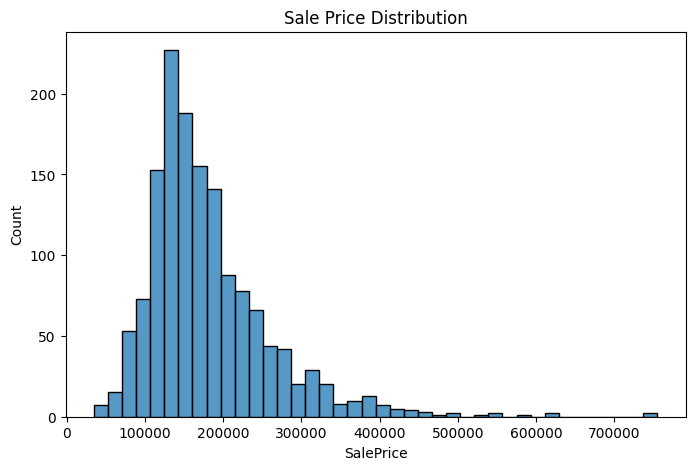

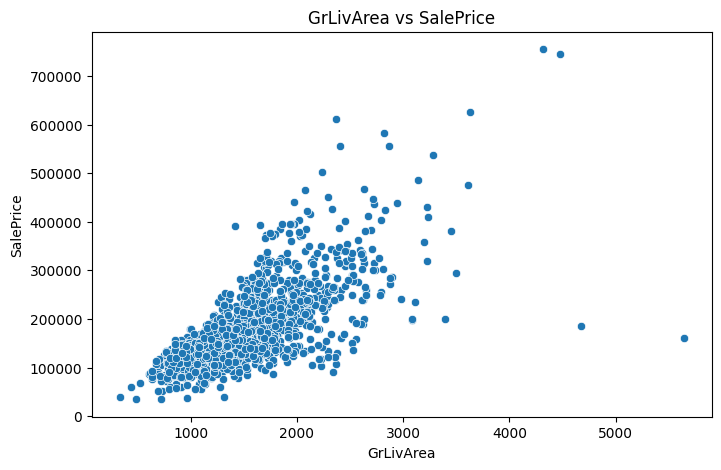

RMSLE: 0.20262469969396554


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
train.head()

# Graph 1: Sale price distribution
plt.figure(figsize=(8,5))
sns.histplot(train["SalePrice"], bins=40)
plt.title("Sale Price Distribution")
plt.show()

# Graph 2: Living area vs price
plt.figure(figsize=(8,5))
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])
plt.title("GrLivArea vs SalePrice")
plt.show()

continuous_features = ["LotArea", "GrLivArea"]
categorical_features = ["Neighborhood", "HouseStyle"]

target = "SalePrice"

train[continuous_features] = train[continuous_features].fillna(train[continuous_features].mean())
train[categorical_features] = train[categorical_features].fillna("Unknown")

encoded = pd.get_dummies(train[categorical_features])

scaler = StandardScaler()
scaled_cont = scaler.fit_transform(train[continuous_features])
scaled_cont = pd.DataFrame(scaled_cont, columns=continuous_features)

X = pd.concat([scaled_cont, encoded], axis=1)
y = train[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

def compute_rmsle(y_true, y_pred):
    log_true = np.log1p(y_true)
    log_pred = np.log1p(y_pred)
    return np.sqrt(mean_squared_error(log_true, log_pred))

score = compute_rmsle(y_val, y_pred)

print("RMSLE:", score)